# Human Activity Recognition with a 1D CNN

**SE4050 – Deep Learning** · UCI Smartphone-Based Recognition of Human Activities and Postural Transitions (HAPT)

This notebook runs the project's CNN pipeline end to end:

1. Load the windowed sensor data (128 samples × 6 channels, subject-level split)
2. Explore the class distribution
3. Normalise with statistics from the training set only
4. Build and train the 1D CNN (`src/models.py`, `src/training.py`)
5. Evaluate once on the unseen test subjects: accuracy, precision, recall, F1, ROC-AUC, confusion matrix

## 1. Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, f1_score,
                             matthews_corrcoef, precision_score, recall_score, roc_auc_score)
from sklearn.preprocessing import StandardScaler
from tensorflow import keras

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from models import build_cnn
from training import compute_class_weights, train_cnn

SEED = 42
keras.utils.set_random_seed(SEED)

PROCESSED_DIR = ROOT / "data" / "processed"
MODEL_PATH = ROOT / "models" / "cnn" / "cnn_model_notebook.keras"  # the final cnn_model.keras is left untouched

CLASS_NAMES = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS", "SITTING", "STANDING", "LAYING",
               "STAND_TO_SIT", "SIT_TO_STAND", "SIT_TO_LIE", "LIE_TO_SIT", "STAND_TO_LIE", "LIE_TO_STAND"]
BLUE, ORANGE = "#2a78d6", "#eb6834"
print("Project root:", ROOT)

Project root: D:\Y4S1(jul-Dec-2026)\DeepLearning\Assignment\DL-Assignment\SE4050-DL-Human-Activity-Recognition


## 2. Load the windowed data

The arrays were produced by `src/preprocessing.py` (run `python src/preprocessing.py --build` if they are missing):

- Each window is **128 samples (2.56 s at 50 Hz) × 6 channels** (accelerometer + gyroscope x, y, z), with 50% overlap.
- Windows are cut inside each labelled activity segment, so no window mixes two activities.
- The split is **by subject**: no person appears in more than one split.

In [2]:
data = {}
for split in ["train", "val", "test"]:
    data[split] = {
        "X": np.load(PROCESSED_DIR / f"X_{split}.npy"),
        "y": np.load(PROCESSED_DIR / f"y_{split}.npy") - 1,  # activity 1-12 -> class 0-11
        "subjects": np.load(PROCESSED_DIR / f"subjects_{split}.npy"),
    }
    print(f"{split:>5}: X {data[split]['X'].shape}, subjects {sorted(np.unique(data[split]['subjects']).tolist())}")

subject_sets = {s: set(np.unique(data[s]["subjects"])) for s in data}
assert not (subject_sets["train"] & subject_sets["val"]), "train/val subject overlap"
assert not (subject_sets["train"] & subject_sets["test"]), "train/test subject overlap"
assert not (subject_sets["val"] & subject_sets["test"]), "val/test subject overlap"
print("Subject-level split verified: no subject is shared between splits.")

train: X (6212, 128, 6), subjects [5, 6, 7, 8, 11, 14, 15, 16, 17, 19, 21, 22, 23, 26, 28, 29, 30]
  val: X (1555, 128, 6), subjects [1, 3, 25, 27]
 test: X (3162, 128, 6), subjects [2, 4, 9, 10, 12, 13, 18, 20, 24]
Subject-level split verified: no subject is shared between splits.


## 3. Exploratory data analysis: class distribution

Activity              Train    Val   Test   Total      %
WALKING                 942    284    496    1722  15.8%
WALKING_UPSTAIRS        845    228    471    1544  14.1%
WALKING_DOWNSTAIRS      787    200    420    1407  12.9%
SITTING                1056    237    508    1801  16.5%
STANDING               1148    275    556    1979  18.1%
LAYING                 1151    262    545    1958  17.9%
STAND_TO_SIT             37     10     23      70   0.6%
SIT_TO_STAND             18      5     10      33   0.3%
SIT_TO_LIE               62     13     32     107   1.0%
LIE_TO_SIT               46     14     25      85   0.8%
STAND_TO_LIE             74     16     49     139   1.3%
LIE_TO_STAND             46     11     27      84   0.8%


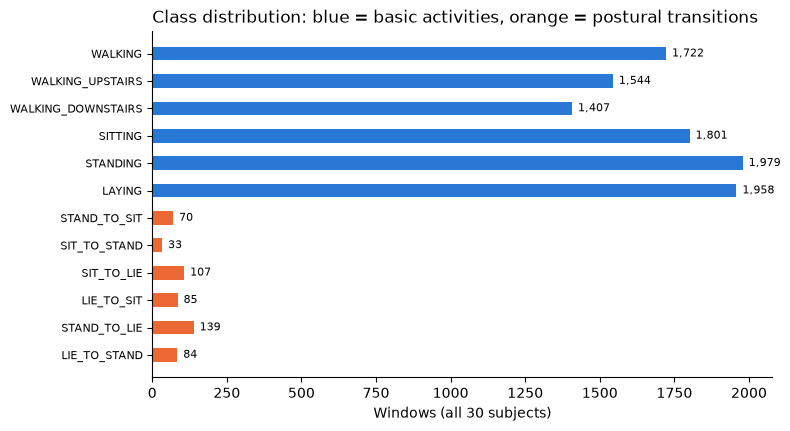

Largest / smallest class = 60 : 1 -> class weights are needed


In [3]:
counts = {s: np.bincount(data[s]["y"], minlength=12) for s in data}
total = counts["train"] + counts["val"] + counts["test"]

print(f"{'Activity':<20}{'Train':>7}{'Val':>7}{'Test':>7}{'Total':>8}{'%':>7}")
for k, name in enumerate(CLASS_NAMES):
    print(f"{name:<20}{counts['train'][k]:>7}{counts['val'][k]:>7}{counts['test'][k]:>7}"
          f"{total[k]:>8}{100 * total[k] / total.sum():>6.1f}%")

fig, ax = plt.subplots(figsize=(8, 4.5))
rows = np.arange(12)[::-1]
ax.barh(rows, total, height=0.5, color=[BLUE] * 6 + [ORANGE] * 6)
for r, v in zip(rows, total):
    ax.text(v + 20, r, f"{v:,}", va="center", fontsize=8)
ax.set_yticks(rows, CLASS_NAMES, fontsize=8)
ax.set_xlabel("Windows (all 30 subjects)")
ax.set_title("Class distribution: blue = basic activities, orange = postural transitions", loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

print(f"Largest / smallest class = {total.max() / total.min():.0f} : 1 -> class weights are needed")

## 4. Preprocessing

- **Normalisation:** a per-channel `StandardScaler` is fitted on the **training windows only**, then applied to validation and test data (no information from the test set leaks in).
- **Class weights:** balanced weights computed from the training labels, so the rare transitions are not ignored.

In [4]:
scaler = StandardScaler().fit(data["train"]["X"].reshape(-1, 6))

def scale(X):
    return scaler.transform(X.reshape(-1, 6)).reshape(X.shape).astype("float32")

X_train, y_train = scale(data["train"]["X"]), data["train"]["y"]
X_val, y_val = scale(data["val"]["X"]), data["val"]["y"]
X_test, y_test = scale(data["test"]["X"]), data["test"]["y"]

print("Train channel means after scaling:", X_train.reshape(-1, 6).mean(axis=0).round(3))
print("Train channel stds after scaling: ", X_train.reshape(-1, 6).std(axis=0).round(3))

class_weights = compute_class_weights(y_train)
for k, w in class_weights.items():
    print(f"  {CLASS_NAMES[k]:<20} weight {w:.3f}")

Train channel means after scaling: [-0. -0.  0. -0.  0. -0.]
Train channel stds after scaling:  [1. 1. 1. 1. 1. 1.]
  WALKING              weight 0.550
  WALKING_UPSTAIRS     weight 0.613
  WALKING_DOWNSTAIRS   weight 0.658
  SITTING              weight 0.490
  STANDING             weight 0.451
  LAYING               weight 0.450
  STAND_TO_SIT         weight 13.991
  SIT_TO_STAND         weight 28.759
  SIT_TO_LIE           weight 8.349
  LIE_TO_SIT           weight 11.254
  STAND_TO_LIE         weight 6.995
  LIE_TO_STAND         weight 11.254


## 5. Model: 1D CNN

Three convolution blocks learn short motion patterns from the raw signals; global average pooling summarises them over the window; a small dense head classifies the 12 activities.

In [5]:
model = build_cnn(input_shape=(128, 6), num_classes=12)
model.summary()

Model: "cnn_har"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 128, 32)        │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 32, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,420 (177.42 KB)

 Trainable params: 45,228 (176.67 KB)

 Non-trainable params: 192 (768.00 B)

## 6. Training

Adam (learning rate 0.001), batch size 64, up to 50 epochs. Early stopping watches the **validation loss** (patience 10) and the best epoch is restored and saved, so the test set plays no part in training.

In [6]:
history, train_seconds = train_cnn(
    model, X_train, y_train, X_val, y_val,
    epochs=50, batch_size=64, use_class_weight=True, model_path=MODEL_PATH, patience=10,
)
h = history.history
best_epoch = int(np.argmin(h["val_loss"])) + 1
print(f"Trained {len(h['loss'])} epochs in {train_seconds:.1f} s; best epoch = {best_epoch}")

Epoch 1/50


98/98 - 4s - 44ms/step - accuracy: 0.5597 - loss: 1.6264 - val_accuracy: 0.7846 - val_loss: 0.9204


Epoch 2/50


98/98 - 2s - 17ms/step - accuracy: 0.7226 - loss: 1.0611 - val_accuracy: 0.9260 - val_loss: 0.4414


Epoch 3/50


...

Epoch 29/50


98/98 - 2s - 18ms/step - accuracy: 0.9327 - loss: 0.2449 - val_accuracy: 0.9633 - val_loss: 0.1029


Epoch 30/50


98/98 - 2s - 17ms/step - accuracy: 0.9342 - loss: 0.2133 - val_accuracy: 0.9563 - val_loss: 0.1237


Trained 30 epochs in 49.3 s; best epoch = 20


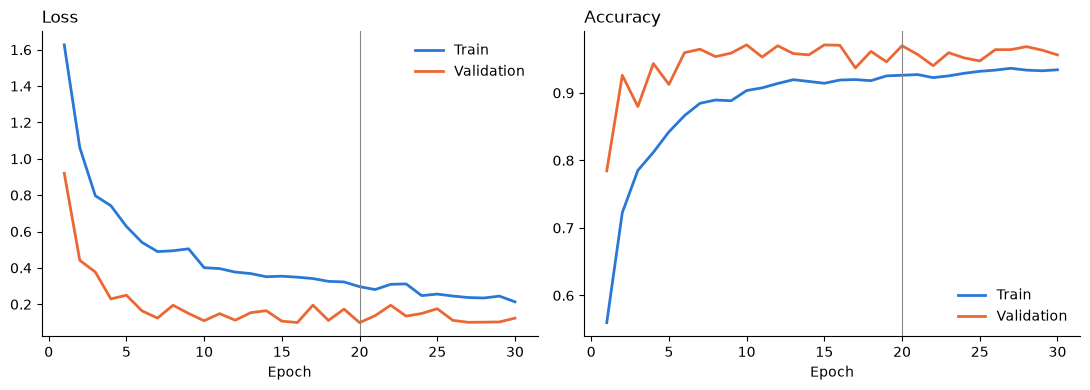

Note: the training loss includes class weights and dropout, so it sits above the validation loss.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (key, title) in zip(axes, [("loss", "Loss"), ("accuracy", "Accuracy")]):
    epochs = np.arange(1, len(h[key]) + 1)
    ax.plot(epochs, h[key], color=BLUE, linewidth=2, label="Train")
    ax.plot(epochs, h[f"val_{key}"], color=ORANGE, linewidth=2, label="Validation")
    ax.axvline(best_epoch, color="#898781", linewidth=0.8)
    ax.set_title(title, loc="left")
    ax.set_xlabel("Epoch")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False)
plt.tight_layout()
plt.show()
print("Note: the training loss includes class weights and dropout, so it sits above the validation loss.")

## 7. Evaluation on the unseen test subjects

In [8]:
best_model = keras.models.load_model(MODEL_PATH)
proba = best_model.predict(X_test, batch_size=256, verbose=0)
y_pred = proba.argmax(axis=1)
transition = y_test >= 6

results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision (macro)": precision_score(y_test, y_pred, average="macro", zero_division=0),
    "Recall (macro)": recall_score(y_test, y_pred, average="macro", zero_division=0),
    "F1-score (macro)": f1_score(y_test, y_pred, average="macro", zero_division=0),
    "F1-score (weighted)": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    "ROC-AUC (macro, one-vs-rest)": roc_auc_score(y_test, proba, multi_class="ovr", average="macro"),
    "MCC": matthews_corrcoef(y_test, y_pred),
    "Accuracy - basic activities": accuracy_score(y_test[~transition], y_pred[~transition]),
    "Accuracy - transitions": accuracy_score(y_test[transition], y_pred[transition]),
}
for name, value in results.items():
    print(f"{name:<30} {value:.4f}")

Accuracy                       0.8950
Precision (macro)              0.8138
Recall (macro)                 0.8511
F1-score (macro)               0.8188
F1-score (weighted)            0.8953
ROC-AUC (macro, one-vs-rest)   0.9940
MCC                            0.8770
Accuracy - basic activities    0.9035
Accuracy - transitions         0.7410


In [9]:
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4, zero_division=0))

                    precision    recall  f1-score   support

           WALKING     0.9749    0.9415    0.9579       496
  WALKING_UPSTAIRS     0.9910    0.9321    0.9606       471
WALKING_DOWNSTAIRS     0.8906    0.9881    0.9368       420
           SITTING     0.8284    0.7224    0.7718       508
          STANDING     0.7953    0.8525    0.8229       556
            LAYING     0.9982    1.0000    0.9991       545
      STAND_TO_SIT     0.4200    0.9130    0.5753        23
      SIT_TO_STAND     0.9091    1.0000    0.9524        10
        SIT_TO_LIE     0.6042    0.9062    0.7250        32
        LIE_TO_SIT     0.7917    0.7600    0.7755        25
      STAND_TO_LIE     0.8125    0.5306    0.6420        49
      LIE_TO_STAND     0.7500    0.6667    0.7059        27

          accuracy                         0.8950      3162
         macro avg     0.8138    0.8511    0.8188      3162
      weighted avg     0.9011    0.8950    0.8953      3162



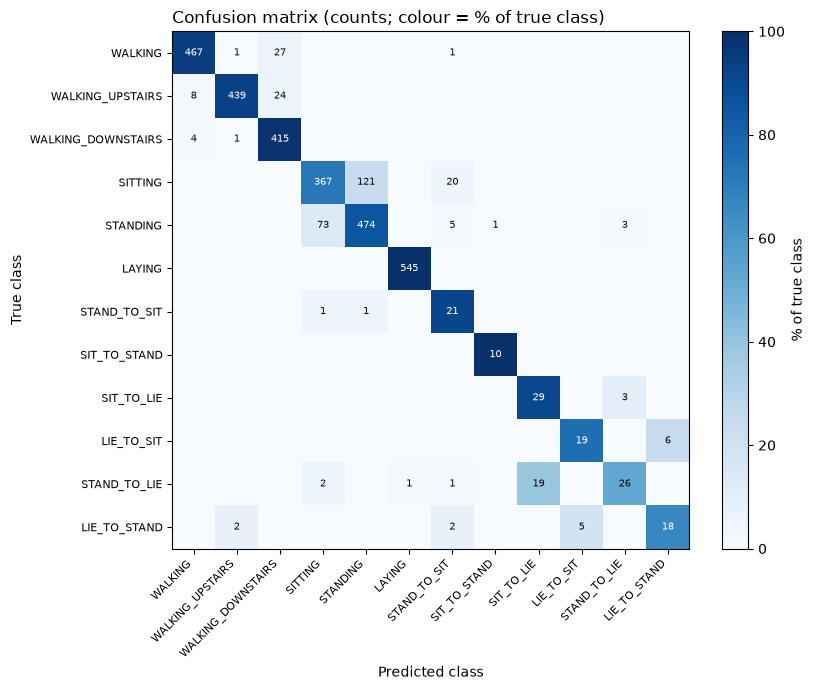

In [10]:
cm = confusion_matrix(y_test, y_pred, labels=range(12))
pct = 100 * cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(pct, cmap="Blues", vmin=0, vmax=100)
ax.set_xticks(range(12), CLASS_NAMES, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(12), CLASS_NAMES, fontsize=8)
for i in range(12):
    for j in range(12):
        if cm[i, j]:
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7,
                    color="white" if pct[i, j] > 55 else "#0b0b0b")
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("Confusion matrix (counts; colour = % of true class)", loc="left")
fig.colorbar(im, ax=ax, fraction=0.04, label="% of true class")
plt.tight_layout()
plt.show()

## 8. Summary

- **Macro-F1** is the main metric: 95% of windows are basic activities, so accuracy alone hides mistakes on the six rare transitions.
- The largest error is **sitting ↔ standing**: both are motionless and differ only slightly in the phone's tilt.
- Transitions have very few test windows (10–49 per class), so their per-class scores change a lot with a single window.
- Because this run uses a fixed seed on CPU, results may differ slightly from the saved final model; `experiments/cnn_seed_study.py` measures that run-to-run spread.